In [1]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

import os

import pandas as pd

import h5py
from scipy.optimize import curve_fit
from scipy.spatial.distance import cdist
from scipy.stats import binned_statistic

import pynbody
from pynbody.analysis import profile

from cosmoSim import cosmoSim

In [2]:
data_path = '/home/ryan/Data/'
base_path="/home/ryan/projects/Medvedev/data_product_generation/data_products/data_prods/"

bins_per_decade = 20

In [3]:
colors = {
    'CDM': 'r',
    '2cDM': {
        '[0, 0]': 'b',
        '[-2, -2]': 'g',
    },
    'SIDM': {
        '[0]': 'm',
        '[-2]': 'c'
    },
}
dashings = {
    'HY': 'solid',
    'DM': 'dashed'
}

softening_length = 0.441 # in kpc

RUNS = [
    'run_CDM_DREAMS948_DM_dir_1',
    'run_CDM_DREAMS948_HY_dir_0',
    'run_2cDM_DREAMS948_DM_power00_sigma1_dir_7_Vkick100.00',
    'run_2cDM_DREAMS948_HY_power00_sigma1_dir_6_Vkick100.00',
    'run_2cDM_DREAMS948_DM_powerm2m2_sigma1_dir_9_Vkick100.00',
    'run_2cDM_DREAMS948_HY_powerm2m2_sigma1_dir_8_Vkick100.00',
    'run_SIDM_DREAMS948_DM_power0_sigma1_dir_3',
    'run_SIDM_DREAMS948_HY_power0_sigma1_dir_2',
    'run_SIDM_DREAMS948_DM_powerm2_sigma1_dir_5',
    'run_SIDM_DREAMS948_HY_powerm2_sigma1_dir_4',
]

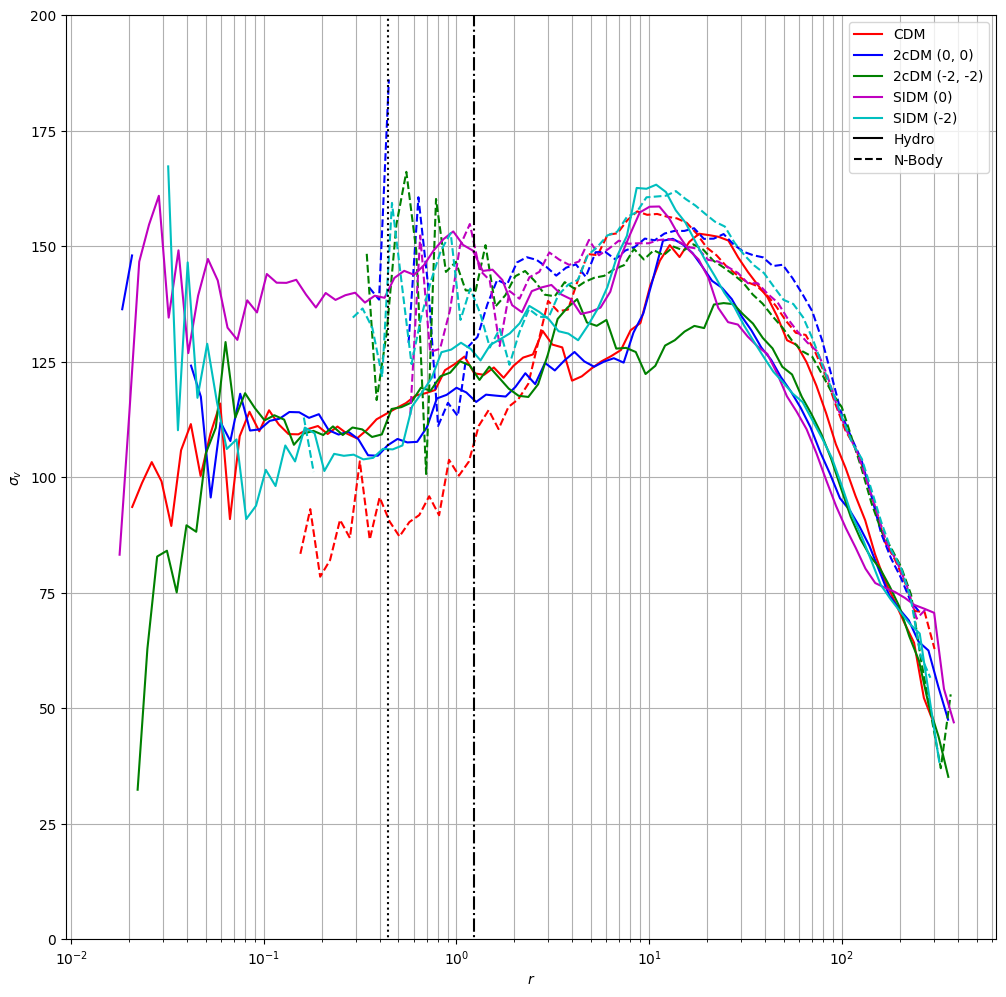

In [9]:
softening_length = 0.441 # in kpc

fig, ax = plt.subplots( 1, 1, figsize=[12, 12] )

for run_n in RUNS:
    snap_path = data_path + f'/{run_n}/snap_127.hdf5'
    run = cosmoSim(run_n, base_path=base_path)
    s = pynbody.load(snap_path)
    h = s.halos(subhalos=True)

    s.physical_units()
    s['rho']; s['smooth'] # force KDTree to be built and density estimations made
    pynbody.analysis.faceon(h[0])

    linestyle = dashings[run.baryon_type]
    if run.dm_type == 'CDM':
        color = colors[run.dm_type]
    else:
        color = colors[run.dm_type][str(run.powerLaws)]

    r = h[0]['r']
    # jz = np.abs(h[0]['jz'])
    # j2 = h[0]['j2']
    vdisp = h[0]['v_disp']

    nbins = int( (np.amax(np.log10(r)) - np.amin(np.log10(r))) * bins_per_decade )
    r_bins = np.geomspace(np.amin(r), np.amax(r), num=nbins)

    # jz_binned = binned_statistic(r, jz, statistic='mean', bins=r_bins)
    # jz_std = binned_statistic(r, jz, statistic='std', bins=r_bins)

    # j2_binned = binned_statistic(r, j2, statistic='mean', bins=r_bins)
    # j2_std = binned_statistic(r, j2, statistic='std', bins=r_bins)

    vdisp_binned = binned_statistic(r, vdisp, statistic='mean', bins=r_bins)
    vdisp_std = binned_statistic(r, vdisp, statistic='std', bins=r_bins)

    bin_centers = (r_bins[:-1] + r_bins[1:]) / 2

    # fig, ax = plt.subplots( 1, 1, figsize=[12, 12] )
    # # ax.errorbar( bin_centers, jz_binned.statistic, yerr=jz_std.statistic)
    # ax.plot( bin_centers, jz_binned.statistic )
    # ax.set_xlabel(r'$r$')
    # ax.set_ylabel(r'$|J_z|$')
    # ax.set_title(run_n)

    # ax.vlines(softening_length, 0, 10**10, colors='k', linestyles='dotted')
    # ax.vlines(2.8*softening_length, 0, 10**10, colors='k', linestyles='dashdot')

    # ax.set_ylim(10**0, 10**4)
    # ax.grid(True, which="both", ls="-")
    # ax.set_aspect( 'auto', adjustable='box' )
    # ax.set_yscale("log")
    # ax.set_xscale("log")
    # plt.show()

    # fig, ax = plt.subplots( 1, 1, figsize=[12, 12] )
    # # ax.errorbar( bin_centers, j2_binned.statistic, yerr=j2_std.statistic)
    # ax.plot( bin_centers, j2_binned.statistic )
    # ax.set_xlabel(r'$r$')
    # ax.set_ylabel(r'$J^2$')
    # ax.set_title(run_n)

    # ax.vlines(softening_length, 0, 10**10, colors='k', linestyles='dotted')
    # ax.vlines(2.8*softening_length, 0, 10**10, colors='k', linestyles='dashdot')

    # ax.set_ylim(10**0, 10**10)
    # ax.grid(True, which="both", ls="-")
    # ax.set_aspect( 'auto', adjustable='box' )
    # ax.set_yscale("log")
    # ax.set_xscale("log")
    # plt.show()


    # fig, ax = plt.subplots( 1, 1, figsize=[12, 12] )
    # ax.errorbar( bin_centers, vdisp_binned.statistic, yerr=vdisp_std.statistic)
    ax.plot( bin_centers, vdisp_binned.statistic, color=color, linestyle=linestyle )

ax.plot([],[], label='CDM', color='r')
ax.plot([],[], label='2cDM (0, 0)', color='b')
ax.plot([],[], label='2cDM (-2, -2)', color='g')
ax.plot([],[], label='SIDM (0)', color='m')
ax.plot([],[], label='SIDM (-2)', color='c')
ax.plot([],[], label='Hydro', color='k', linestyle='solid')
ax.plot([],[], label='N-Body', color='k', linestyle='dashed')
ax.set_xlabel(r'$r$')
ax.set_ylabel(r'$\sigma_v$')
# ax.set_title(run_n)

ax.vlines(softening_length, -10**10, 10**10, colors='k', linestyles='dotted')
ax.vlines(2.8*softening_length, -10**10, 10**10, colors='k', linestyles='dashdot')

ax.set_ylim(0, 200)
ax.grid(True, which="both", ls="-")
ax.set_aspect( 'auto', adjustable='box' )
ax.set_xscale("log")
plt.legend()
plt.show()

/home/ryan/projects/Medvedev/2cDM_paperII/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


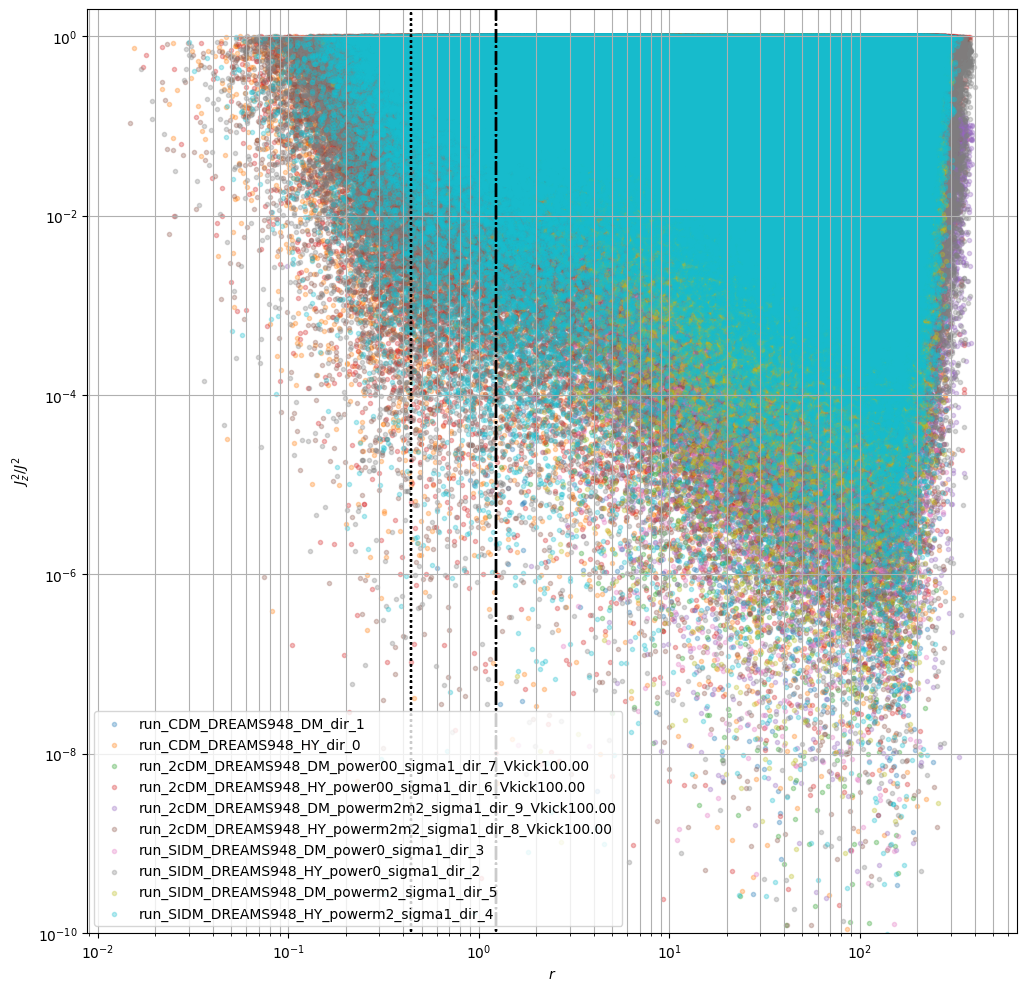

In [5]:
softening_length = 0.441 # in kpc

fig, ax = plt.subplots( 1, 1, figsize=[12, 12] )
for run_n in RUNS:
    snap_path = data_path + f'/{run_n}/snap_127.hdf5'
    # run = cosmoSim(run_n, base_path=base_path)
    s = pynbody.load(snap_path)
    h = s.halos(subhalos=True)

    s.physical_units()
    s['rho']; s['smooth'] # force KDTree to be built and density estimations made
    pynbody.analysis.faceon(h[0])

    r = h[0]['r']
    jz = h[0]['jz']**2
    j2 = h[0]['j2']

    jzj2 = jz / j2

    # fig, ax = plt.subplots( 1, 1, figsize=[12, 12] )
    # ax.scatter( j2, jz, marker='.', alpha=0.3 )
    # ax.set_xlabel(r'$J^2$')
    # ax.set_ylabel(r'$|J_z|$')
    # ax.set_title(run_n)

    # # ax.set_ylim(10**0, 10**10)
    # ax.grid(True, which="both", ls="-")
    # ax.set_aspect( 'auto', adjustable='box' )
    # ax.set_yscale("log")
    # ax.set_xscale("log")
    # plt.show()

    ax.scatter( r, jzj2, marker='.', alpha=0.3, label=run_n )
    ax.set_xlabel(r'$r$')
    ax.set_ylabel(r'$J_z^2/J^2$')

    ax.vlines(softening_length, -10**10, 10**10, colors='k', linestyles='dotted')
    ax.vlines(2.8*softening_length, -10**10, 10**10, colors='k', linestyles='dashdot')

    ax.set_ylim(10**-10, 2*10**0)

    ax.grid(True, which="both", ls="-")
    ax.set_aspect( 'auto', adjustable='box' )
    ax.set_yscale("log")
    ax.set_xscale("log")
plt.legend()
plt.show()